# Nibabel Basics Notebook
### *Learning how to load and view MRI scans*

## Import Libraries
We need nibabel for MRI files and matplotlib for plotting.

In [1]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

## Upload an MRI File (.nii.gz)
Upload any NIfTI file.

In [15]:
from google.colab import files
uploaded = files.upload()

Saving BraTS20_Training_006_t2.nii to BraTS20_Training_006_t2 (1).nii


## Load MRI File
Nibabel loads the 3D MRI volume as a NumPy array.

In [16]:
file_path = '/content/BraTS20_Training_006_t2.nii'
mri = nib.load(file_path).get_fdata()
print('MRI Shape:', mri.shape)

MRI Shape: (240, 240, 155)


## Visualize a Middle Slice
MRI is 3D. We view one slice at a time.

(np.float64(-0.5), np.float64(239.5), np.float64(239.5), np.float64(-0.5))

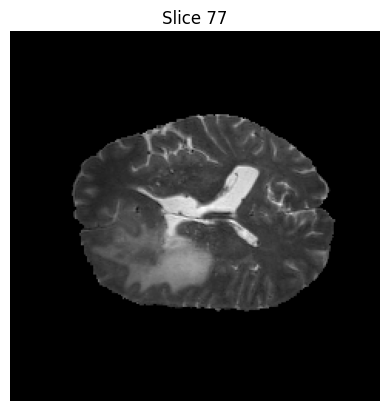

In [17]:
slice_index = mri.shape[2] // 2
plt.imshow(mri[:, :, slice_index], cmap='gray')
plt.title(f'Slice {slice_index}')
plt.axis('off')

## Extract All Slices
Convert 3D MRI into 2D slices.

In [18]:
slices = [mri[:, :, i] for i in range(mri.shape[2])]
len(slices)

155

## Normalize a Slice
Normalization improves contrast.

(np.float64(-0.5), np.float64(239.5), np.float64(239.5), np.float64(-0.5))

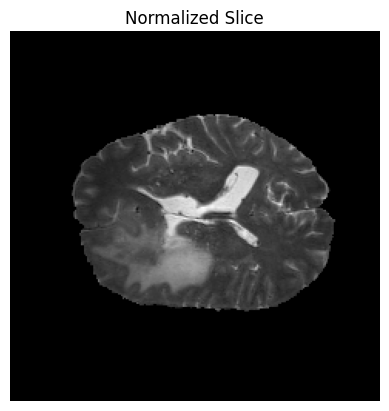

In [19]:
norm_slice = (mri[:, :, slice_index] - np.min(mri)) / (np.max(mri) - np.min(mri))
plt.imshow(norm_slice, cmap='gray')
plt.title('Normalized Slice')
plt.axis('off')

## Resize Slice (Used in ML Preprocessing)

(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

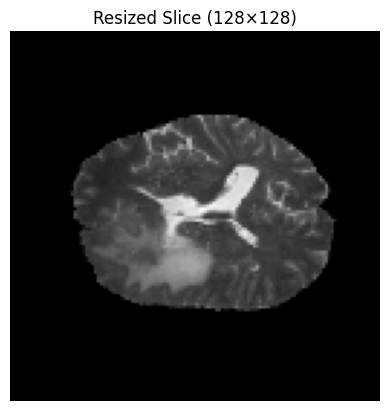

In [20]:
import tensorflow as tf
resized = tf.image.resize(norm_slice[..., None], (128, 128))
plt.imshow(resized.numpy().squeeze(), cmap='gray')
plt.title('Resized Slice (128×128)')
plt.axis('off')

## **Exercises**
1. Load **another** MRI file and visualize 5 slices.
2. Write a function `plot_slices(volume, indices)` to plot given slice numbers.
3. Create a function to normalize **all** slices and return the new array.
4. Resize all slices to 128×128 and count how many slices contain tumor pixels (if mask available).


---
* MRI File: https://www.kaggle.com/datasets/suchi21/my-mri-nii-gz

In [6]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [5]:
from google.colab import files
uploaded = files.upload()

Saving BraTS20_Training_006_t2.nii to BraTS20_Training_006_t2.nii


In [7]:
mri_path = "/content/BraTS20_Training_006_t2.nii"

img = nib.load(mri_path)
volume = img.get_fdata()

print("Volume shape:", volume.shape)
print("Data type:", volume.dtype)

Volume shape: (240, 240, 155)
Data type: float64


In [8]:
def plot_slices(volume, indices, cmap="gray"):
    plt.figure(figsize=(3 * len(indices), 3))
    for i, idx in enumerate(indices):
        plt.subplot(1, len(indices), i+1)
        plt.imshow(volume[:, :, idx], cmap=cmap)
        plt.title(f"Slice {idx}")
        plt.axis("off")
    plt.show()

* For BraTS, z-score normalization inside non-zero region is best

In [9]:
def normalize_volume(volume, eps=1e-8):
    """
    Z-score normalization using only non-zero voxels
    """
    mask = volume > 0
    mean = volume[mask].mean()
    std = volume[mask].std()

    norm = np.zeros_like(volume)
    norm[mask] = (volume[mask] - mean) / (std + eps)
    return norm

In [10]:
norm_volume = normalize_volume(volume)
print("Mean (non-zero):", norm_volume[volume > 0].mean())
print("Std (non-zero):", norm_volume[volume > 0].std())

Mean (non-zero): 7.963605545363176e-17
Std (non-zero): 0.9999999998411616


In [11]:
def resize_volume(volume, target_size=(128, 128)):
    H, W, D = volume.shape
    resized = np.zeros((target_size[0], target_size[1], D), dtype=np.float32)

    for i in range(D):
        resized[:, :, i] = cv2.resize(
            volume[:, :, i],
            target_size,
            interpolation=cv2.INTER_LINEAR
        )
    return resized
resized_volume = resize_volume(norm_volume)
print("Resized shape:", resized_volume.shape)

Resized shape: (128, 128, 155)


In [12]:
mask_path = "/content/BraTS20_Training_006_t2.nii"
mask = nib.load(mask_path).get_fdata()

In [13]:
def count_tumor_slices(mask):
    count = 0
    tumor_indices = []

    for i in range(mask.shape[2]):
        if np.any(mask[:, :, i] > 0):
            count += 1
            tumor_indices.append(i)

    return count, tumor_indices
tumor_count, tumor_slices = count_tumor_slices(mask)
print("Tumor slices:", tumor_count)

Tumor slices: 141


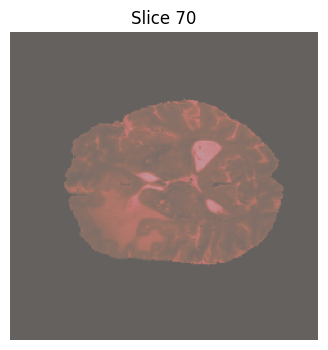

In [14]:
def plot_mri_with_mask(volume, mask, idx):
    plt.figure(figsize=(4, 4))
    plt.imshow(volume[:, :, idx], cmap="gray")
    plt.imshow(mask[:, :, idx], cmap="Reds", alpha=0.4)
    plt.title(f"Slice {idx}")
    plt.axis("off")
    plt.show()
plot_mri_with_mask(volume, mask, tumor_slices[len(tumor_slices)//2])